# Post-hoc robustness diagnostics for Notebooks 71 and 73

**Objective.** Bound the two newest results before they enter the write-up:
the FNSPID conditional negative-share coefficient (Notebook 71) and the
backward LSEG negative-pressure downside result (Notebook 73).

**Status.** These are labelled post-hoc diagnostics on already-opened data.
Nothing here is a frozen gate, nothing can promote or reverse a frozen
result, and no seed, threshold, or estimand from the original notebooks is
changed. The questions are the ones an examiner asks: is the coefficient
stable over time, does it exist on genuinely multi-story days, is the
downside result one episode in disguise, and does the inference survive
reasonable dependence assumptions?

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "final_experiments":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from final_experiments.lib.conditional_aggregation import (  # noqa: E402
    conditional_negative_share_test,
    hac_mean_coefficient,
)
from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    apply_house_style,
    zero_line,
)
from final_experiments.lib.volatility_target import (  # noqa: E402
    paired_circular_block_mean,
)

apply_house_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

OUTPUT = ROOT / "final_experiments/outputs/74_conditional_and_pressure_robustness_diagnostics"
OUTPUT.mkdir(parents=True, exist_ok=True)

NB71_OUTPUT = ROOT / "final_experiments/outputs/71_conditional_negative_share_transfer"
NB73_OUTPUT = ROOT / "final_experiments/outputs/73_lseg_negative_pressure_har_backward_transfer"
FNSPID_PATH = ROOT / "final_experiments/outputs/03_aggregation/firm_day_aggregators.parquet"

# Frozen Notebook 71 headline numbers, reproduced before any diagnostic runs.
FROZEN_71 = {"estimate": -0.008310, "ci_low": -0.014100, "ci_high": -0.002520}
# Frozen Notebook 73 primary means (overlay minus HAR net return; HAR minus
# overlay downside-squared return).
FROZEN_73 = {"return_mean": 0.000014, "downside_mean": 0.000005}

DIAGNOSTIC_SEED = 20260840  # new seed family; original frozen seeds untouched

## Part A — stability of the conditional negative-share coefficient

The frozen claim rests on one number: the mean daily negative-share rank
coefficient over 2,264 development sessions. These diagnostics ask whether
that mean is a broad property of the period or an artefact of a few years,
a lag choice, or single-story firm-days where "the tail of the day's
distribution" is just a recode of the only story.

In [2]:
daily71 = pd.read_csv(
    NB71_OUTPUT / "fnspid_finbert_development_daily_coefficients.csv",
    parse_dates=["session_date"],
)
reproduced = hac_mean_coefficient(daily71, coefficient_col="beta_negative_share", hac_lags=5)
assert abs(reproduced["estimate"] - FROZEN_71["estimate"]) < 5e-6, reproduced
assert abs(reproduced["ci_low"] - FROZEN_71["ci_low"]) < 5e-5, reproduced
display(
    Markdown(
        f"Reproduced the frozen headline coefficient from the saved daily series: "
        f"{reproduced['estimate']:.6f} [{reproduced['ci_low']:.6f}, {reproduced['ci_high']:.6f}], "
        f"p = {reproduced['p_two_sided']:.4f} on {reproduced['n_clusters']} sessions."
    )
)

Reproduced the frozen headline coefficient from the saved daily series: -0.008310 [-0.014100, -0.002520], p = 0.0049 on 2264 sessions.

### A1. Year-by-year coefficient

In [3]:
yearly_rows = []
for year, block in daily71.groupby(daily71["session_date"].dt.year):
    result = hac_mean_coefficient(block, coefficient_col="beta_negative_share", hac_lags=5)
    yearly_rows.append(
        {
            "year": int(year),
            "n_sessions": result["n_clusters"],
            "estimate": result["estimate"],
            "ci_low": result["ci_low"],
            "ci_high": result["ci_high"],
            "p_two_sided": result["p_two_sided"],
        }
    )
yearly = pd.DataFrame(yearly_rows)
yearly["negative"] = yearly["estimate"] < 0
yearly.to_csv(OUTPUT / "yearly_negative_share_coefficients.csv", index=False)
display(yearly)
display(
    Markdown(
        f"{int(yearly['negative'].sum())} of {len(yearly)} years have a negative point estimate; "
        f"the share of individual development sessions with a negative daily coefficient is "
        f"{float((daily71['beta_negative_share'] < 0).mean()):.3f}."
    )
)

,year,n_sessions,estimate,ci_low,ci_high,p_two_sided,negative
0,2011,252,-0.003453,-0.024404,0.017498,0.746673,True
1,2012,250,-0.006064,-0.023264,0.011135,0.489534,True
2,2013,252,-0.003680,-0.021176,0.013816,0.680143,True
3,2014,252,-0.021345,-0.040302,-0.002388,0.027325,True
4,2015,252,-0.008312,-0.023660,0.007035,0.288431,True
5,2016,252,-0.015599,-0.030960,-0.000238,0.046559,True
6,2017,251,-0.005132,-0.022656,0.012392,0.565979,True
7,2018,251,-0.012577,-0.028939,0.003785,0.131935,True
8,2019,252,0.001385,-0.013798,0.016568,0.858080,False


8 of 9 years have a negative point estimate; the share of individual development sessions with a negative daily coefficient is 0.516.

findfont: Failed to find font weight medium, now using 400.


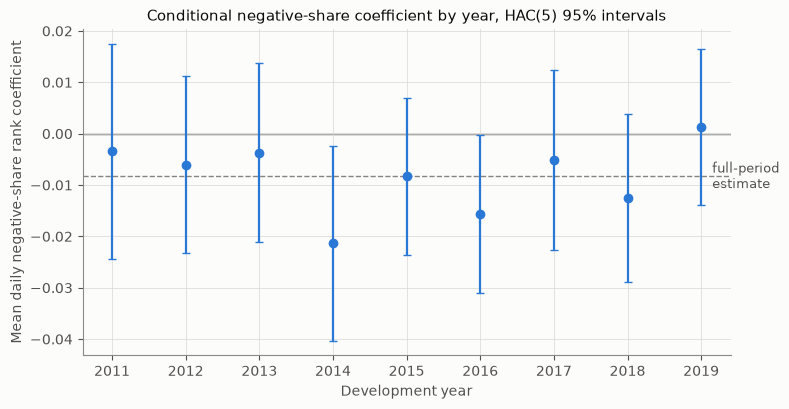

In [4]:
fig, ax = plt.subplots(figsize=(8.0, 4.2))
colour = CATEGORICAL[0]
ax.errorbar(
    yearly["year"],
    yearly["estimate"],
    yerr=[yearly["estimate"] - yearly["ci_low"], yearly["ci_high"] - yearly["estimate"]],
    fmt="o",
    color=colour,
    ecolor=colour,
    elinewidth=1.6,
    capsize=3,
    markersize=6,
)
zero_line(ax)
ax.axhline(FROZEN_71["estimate"], color=INK["reference"], lw=1.0, ls="--", alpha=0.7)
ax.text(
    yearly["year"].iloc[-1] + 0.15,
    FROZEN_71["estimate"],
    "full-period\nestimate",
    color=INK["secondary"],
    fontsize=9,
    va="center",
)
ax.set_xlabel("Development year")
ax.set_ylabel("Mean daily negative-share rank coefficient")
ax.set_title("Conditional negative-share coefficient by year, HAC(5) 95% intervals")
fig.tight_layout()
fig.savefig(OUTPUT / "yearly_negative_share_coefficients.png", dpi=200)
plt.show()

### A2. HAC lag sensitivity

The frozen inference used lag 5. Longer kernels widen the interval if the
daily coefficient series is more persistent than assumed.

In [5]:
lag_rows = []
for lags in (5, 10, 21):
    result = hac_mean_coefficient(daily71, coefficient_col="beta_negative_share", hac_lags=lags)
    lag_rows.append(
        {
            "hac_lags": lags,
            "estimate": result["estimate"],
            "ci_low": result["ci_low"],
            "ci_high": result["ci_high"],
            "p_two_sided": result["p_two_sided"],
        }
    )
lag_sensitivity = pd.DataFrame(lag_rows)
lag_sensitivity.to_csv(OUTPUT / "hac_lag_sensitivity.csv", index=False)
display(lag_sensitivity)

,hac_lags,estimate,ci_low,ci_high,p_two_sided
0,5,-0.008310,-0.014100,-0.002520,0.004907
1,10,-0.008310,-0.014144,-0.002476,0.005244
2,21,-0.008310,-0.014066,-0.002554,0.004660


### A3. Multi-story mechanism check

On a firm-day with one story, negative-story share is a binary recode of
that story's label and "beyond the mean" has no distributional content.
The frozen estimand includes those days by design. This diagnostic reruns
the identical regression on firm-days with at least two, then at least
three, same-day stories. If the coefficient vanishes there, the claim is
about single-story days and the write-up must say so.

In [6]:
panel = pd.read_parquet(FNSPID_PATH)
panel["session_date"] = pd.to_datetime(panel["session_date"])
development = panel.loc[panel["split"] == "development"].copy()
single_share = float((development["n"] == 1).mean())
display(
    Markdown(
        f"Development firm-days: {len(development):,}; share with exactly one story: "
        f"{single_share:.3f}."
    )
)

strata_rows = []
for label, minimum_stories in (("all firm-days (frozen)", 1), ("n >= 2", 2), ("n >= 3", 3)):
    subset = development.loc[development["n"] >= minimum_stories]
    summary, daily_strata, audit = conditional_negative_share_test(
        subset,
        date_col="session_date",
        outcome_col="ar_open_h1",
        mean_col="mean_continuous",
        negative_share_col="negative_share",
        count_col="n",
        min_names=10,
        hac_lags=5,
    )
    strata_rows.append(
        {
            "stratum": label,
            "firm_days": int(len(subset)),
            "sessions_used": audit["dates_used"],
            "estimate": summary["estimate"],
            "ci_low": summary["ci_low"],
            "ci_high": summary["ci_high"],
            "p_two_sided": summary["p_two_sided"],
        }
    )
count_strata = pd.DataFrame(strata_rows)
count_strata.to_csv(OUTPUT / "story_count_strata.csv", index=False)
display(count_strata)

Development firm-days: 512,153; share with exactly one story: 0.483.

,stratum,firm_days,sessions_used,estimate,ci_low,ci_high,p_two_sided
0,all firm-days (frozen),512153,2264,-0.008310,-0.014100,-0.002520,0.004907
1,n >= 2,264683,2264,-0.005291,-0.012723,0.002141,0.162895
2,n >= 3,137142,2262,-0.001828,-0.013850,0.010193,0.765630


## Part B — concentration and dependence checks for the backward pressure result

Notebook 73's surviving numbers are a downside-squared reduction
(q = 0.0336) and a circular-timing pass (q = 0.0482) from 53 risk-off
sessions across 18 entries in 2024–2025. With that few episodes the first
question is concentration: is this one drawdown episode wearing a
significance costume?

In [7]:
state = pd.read_csv(NB73_OUTPUT / "backward_hysteresis_state.csv", parse_dates=["session_date"])
har = pd.read_parquet(NB73_OUTPUT / "frozen_har_daily.parquet")
overlay = pd.read_parquet(NB73_OUTPUT / "har_negative_pressure_overlay_daily.parquet")
for frame in (har, overlay):
    frame["session_date"] = pd.to_datetime(frame["session_date"])

merged = har[["session_date", "net_return"]].merge(
    overlay[["session_date", "net_return"]],
    on="session_date",
    suffixes=("_har", "_overlay"),
    validate="one_to_one",
)
merged = merged.sort_values("session_date").reset_index(drop=True)
merged["d_return"] = merged["net_return_overlay"] - merged["net_return_har"]
merged["d_downside"] = (
    np.minimum(merged["net_return_har"], 0.0) ** 2
    - np.minimum(merged["net_return_overlay"], 0.0) ** 2
)
assert abs(merged["d_return"].mean() - FROZEN_73["return_mean"]) < 5e-6
assert abs(merged["d_downside"].mean() - FROZEN_73["downside_mean"]) < 5e-6
display(
    Markdown(
        f"Reproduced the frozen paired means: return difference "
        f"{merged['d_return'].mean() * 1e4:.3f} bps/session, downside reduction "
        f"{merged['d_downside'].mean() * 1e8:.3f} bps²/session over {len(merged)} sessions."
    )
)

Reproduced the frozen paired means: return difference 0.144 bps/session, downside reduction 517.409 bps²/session over 456 sessions.

### B1. Risk-off episodes and their downside contributions

An episode is a contiguous risk-off run from the frozen hysteresis state.
The session immediately after an exit is attached to its episode so the
re-entry turnover cost is attributed to the episode that caused it.

In [8]:
state = state.sort_values("session_date").reset_index(drop=True)
episode_id = np.full(len(state), -1, dtype=int)
current = 0
for index, row in state.iterrows():
    if bool(row["risk_off_entry"]):
        current += 1
    if bool(row["risk_off"]):
        episode_id[index] = current
    elif index > 0 and episode_id[index - 1] > 0 and not bool(row["risk_off"]):
        # first risk-on session after an exit carries the re-entry cost
        if bool(state.loc[index - 1, "risk_off"]):
            episode_id[index] = episode_id[index - 1]
state["episode"] = episode_id
n_episodes = int(state.loc[state["episode"] > 0, "episode"].nunique())

merged = merged.merge(state[["session_date", "episode"]], on="session_date", validate="one_to_one")
unattributed = merged.loc[merged["episode"] < 0, ["d_return", "d_downside"]].abs().sum()
display(
    Markdown(
        f"{n_episodes} episodes reconstructed (Notebook 73 reports 18 entries). "
        f"Absolute difference mass outside any episode window: return "
        f"{unattributed['d_return']:.2e}, downside {unattributed['d_downside']:.2e} "
        f"(should be ~0: arms coincide when risk-on)."
    )
)

episodes = (
    merged.loc[merged["episode"] > 0]
    .groupby("episode")
    .agg(
        start=("session_date", "min"),
        end=("session_date", "max"),
        n_sessions=("session_date", "size"),
        return_diff_sum=("d_return", "sum"),
        downside_reduction_sum=("d_downside", "sum"),
    )
    .reset_index()
)
total_downside = float(merged["d_downside"].sum())
episodes["downside_share"] = episodes["downside_reduction_sum"] / total_downside
episodes = episodes.sort_values("start").reset_index(drop=True)
episodes.to_csv(OUTPUT / "episode_attribution.csv", index=False)
display(episodes)
top = episodes.loc[episodes["downside_reduction_sum"].idxmax()]
display(
    Markdown(
        f"Largest episode: {top['start'].date()} to {top['end'].date()} "
        f"({int(top['n_sessions'])} sessions) contributes "
        f"{top['downside_share']:.1%} of the total downside-squared reduction."
    )
)

18 episodes reconstructed (Notebook 73 reports 18 entries). Absolute difference mass outside any episode window: return 0.00e+00, downside 0.00e+00 (should be ~0: arms coincide when risk-on).

,episode,start,end,n_sessions,return_diff_sum,downside_reduction_sum,downside_share
0,1,2024-07-18,2024-08-08,16,0.021618,0.000782,0.331627
1,2,2024-09-04,2024-09-09,4,0.004248,0.000101,0.042776
2,3,2024-10-08,2024-10-09,2,-0.004177,-0.000000,-0.000151
3,4,2024-10-24,2024-10-28,3,-0.002031,0.000000,0.000018
4,5,2024-10-30,2024-11-06,6,-0.006430,0.000328,0.138925
5,6,2024-11-13,2024-11-19,5,0.008382,0.000150,0.063536
6,7,2024-11-21,2024-11-22,2,-0.002038,0.000000,0.000000
7,8,2024-12-05,2024-12-06,2,-0.001893,-0.000002,-0.000657
8,9,2024-12-17,2024-12-23,5,0.013129,0.000766,0.324465
9,10,2024-12-30,2025-01-06,5,-0.006276,0.000007,0.003164


Largest episode: 2024-07-18 to 2024-08-08 (16 sessions) contributes 33.2% of the total downside-squared reduction.

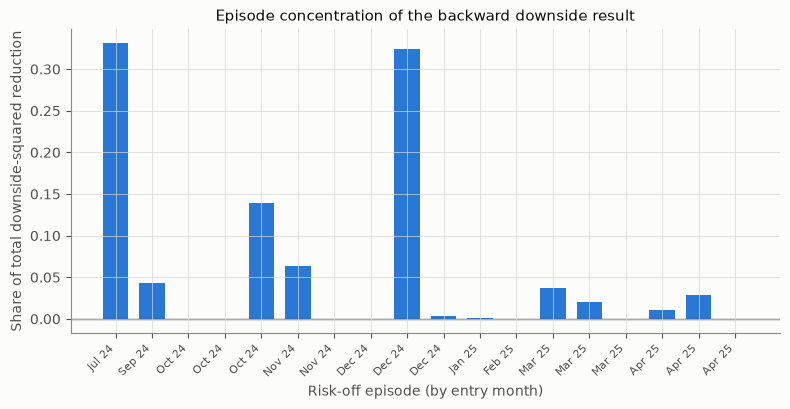

In [9]:
fig, ax = plt.subplots(figsize=(8.0, 4.2))
positions = np.arange(len(episodes))
ax.bar(
    positions,
    episodes["downside_share"],
    color=CATEGORICAL[0],
    width=0.7,
)
zero_line(ax)
ax.set_xticks(positions)
ax.set_xticklabels(
    [f"{row.start:%b %y}" for row in episodes.itertuples()],
    rotation=45,
    ha="right",
    fontsize=8,
)
ax.set_ylabel("Share of total downside-squared reduction")
ax.set_xlabel("Risk-off episode (by entry month)")
ax.set_title("Episode concentration of the backward downside result")
fig.tight_layout()
fig.savefig(OUTPUT / "episode_downside_concentration.png", dpi=200)
plt.show()

### B2. Leave-one-episode-out downside inference

For each episode, the paired difference series is set to zero on that
episode's sessions — as if the state had never fired there — and the
20-session paired circular block bootstrap is re-run on the downside
estimand with a fresh labelled seed. Dropping an episode changes the
estimand, so this is a concentration diagnostic, not a re-test of the
frozen two-test family.

In [10]:
loo_rows = []
for k, episode in enumerate(sorted(episodes["episode"].tolist())):
    mask = merged["episode"] == episode
    modified = merged["d_downside"].where(~mask, 0.0).to_numpy(dtype=float)
    result = paired_circular_block_mean(
        modified,
        block_length=20,
        replications=4999,
        seed=DIAGNOSTIC_SEED + k,
    )
    loo_rows.append(
        {
            "dropped_episode": int(episode),
            "start": episodes.loc[episodes["episode"] == episode, "start"].iloc[0],
            "downside_mean": result["mean"],
            "ci_low": result["ci_low"],
            "ci_high": result["ci_high"],
            "p_two_sided": result["p_two_sided"],
        }
    )
leave_one_out = pd.DataFrame(loo_rows)
leave_one_out["ci_excludes_zero"] = leave_one_out["ci_low"] > 0
leave_one_out.to_csv(OUTPUT / "leave_one_episode_out_downside.csv", index=False)
display(leave_one_out)
worst = leave_one_out.loc[leave_one_out["p_two_sided"].idxmax()]
display(
    Markdown(
        f"Weakest leave-one-out result: dropping the episode entered "
        f"{worst['start']:%Y-%m-%d} gives mean {worst['downside_mean']:.2e}, "
        f"interval [{worst['ci_low']:.2e}, {worst['ci_high']:.2e}], "
        f"p = {worst['p_two_sided']:.4f}. "
        f"{int(leave_one_out['ci_excludes_zero'].sum())} of {len(leave_one_out)} "
        f"drops keep the interval above zero."
    )
)

,dropped_episode,start,downside_mean,ci_low,ci_high,p_two_sided,ci_excludes_zero
0,1,2024-07-18,0.000003,0.000001,0.000008,0.049200,True
1,2,2024-09-04,0.000005,0.000001,0.000010,0.023600,True
2,3,2024-10-08,0.000005,0.000001,0.000010,0.018000,True
3,4,2024-10-24,0.000005,0.000001,0.000010,0.021200,True
4,5,2024-10-30,0.000004,0.000001,0.000009,0.031400,True
5,6,2024-11-13,0.000005,0.000001,0.000010,0.023600,True
6,7,2024-11-21,0.000005,0.000001,0.000010,0.020000,True
7,8,2024-12-05,0.000005,0.000001,0.000010,0.020200,True
8,9,2024-12-17,0.000003,0.000001,0.000007,0.033400,True
9,10,2024-12-30,0.000005,0.000001,0.000010,0.017400,True


Weakest leave-one-out result: dropping the episode entered 2024-07-18 gives mean 3.46e-06, interval [6.17e-07, 7.69e-06], p = 0.0492. 18 of 18 drops keep the interval above zero.

### B3. Block-length sensitivity

The frozen inference fixed 20-session blocks. Shorter blocks assume less
dependence; longer blocks are more conservative when volatility episodes
span a month or more.

In [11]:
block_rows = []
for j, block_length in enumerate((10, 20, 40)):
    for name, series, _frozen_mean in (
        ("overlay_minus_har_net_return", merged["d_return"], FROZEN_73["return_mean"]),
        ("har_minus_overlay_downside_squared", merged["d_downside"], FROZEN_73["downside_mean"]),
    ):
        result = paired_circular_block_mean(
            series.to_numpy(dtype=float),
            block_length=block_length,
            replications=4999,
            seed=DIAGNOSTIC_SEED + 100 + j,
        )
        block_rows.append(
            {
                "estimand": name,
                "block_length": block_length,
                "is_frozen_choice": block_length == 20,
                "mean": result["mean"],
                "ci_low": result["ci_low"],
                "ci_high": result["ci_high"],
                "p_two_sided": result["p_two_sided"],
            }
        )
block_sensitivity = pd.DataFrame(block_rows)
block_sensitivity.to_csv(OUTPUT / "block_length_sensitivity.csv", index=False)
display(block_sensitivity)

,estimand,block_length,is_frozen_choice,mean,ci_low,ci_high,p_two_sided
0,overlay_minus_har_net_return,10,False,0.000014,-0.000140,0.000182,0.860800
1,har_minus_overlay_downside_squared,10,False,0.000005,0.000002,0.000010,0.019400
2,overlay_minus_har_net_return,20,True,0.000014,-0.000133,0.000166,0.848000
3,har_minus_overlay_downside_squared,20,True,0.000005,0.000001,0.000010,0.019000
4,overlay_minus_har_net_return,40,False,0.000014,-0.000113,0.000156,0.830400
5,har_minus_overlay_downside_squared,40,False,0.000005,0.000001,0.000010,0.022600


## Interpretation boundary

These diagnostics are post-hoc and labelled as such. They cannot promote
the backward downside result past its failed full gate, cannot rescue the
LSEG conditional transfer, and cannot tighten the frozen intervals. Their
only legitimate use is in the write-up's robustness language: either the
claims survive these checks and the existing bounded phrasing stands, or
they do not and the phrasing must narrow further (for example, "the
downside reduction is concentrated in one 2025 episode" or "the
conditional coefficient is a single-story-day effect"). No threshold,
seed, or estimand from Notebooks 71–73 changes on the basis of anything
here.